# Regression Task on Spotify Pollen

## 0 Imports

In [83]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

# preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# training & evaluation
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


# Config Files and Python Modules
from importlib import reload

import config
import evaluationTools
import regressionTree
import randomForest

reload(config)
reload(evaluationTools)
reload(regressionTree)
reload(randomForest)

from config import *
from evaluationTools import (
    multiple_sklearn_cross_validate, sklearn_evaluate_holdout_performance,
    multiple_custom_cross_validate, custom_evaluate_holdout_performance
)
from regressionTree import RegressionTree
from randomForest import RandomForest

## 1 Load and Explore Dataset

The Pollen Dataset is a synthetic dataset and can be used to predict pollen density.

### 1.1 Load Raw Data

In [84]:
# Load arff dataset
data_file = '../data/pollen.arff'
data, meta = arff.loadarff(data_file)
df = pd.DataFrame(data)

In [85]:
df.head()

,RIDGE,NUB,CRACK,WEIGHT,DENSITY,OBSERVATION_NUMBER
0,-2.3482,3.6314,5.0289,10.8721,-1.3852,1.0
1,-1.1520,1.4805,3.2375,-0.5939,2.1235,2.0
2,-2.5245,-6.8633,-2.8037,8.4631,-3.4126,3.0
3,5.7523,-6.5091,-5.1510,4.3480,-10.3261,4.0
4,8.7494,-3.8978,-1.3834,-14.8776,-2.4153,5.0


### 1.2 Initial Data Overview

In [86]:
print(f"""
The dataset has following properties:
    - Number of Instances: {df.shape[0]}
    - Number of Columns: {df.shape[1]}
    - Number of Target Attributes: 1
    - Has missing values: {'yes' if df.isnull().sum().sum() > 0 else 'no'}
    - Types of attributes: {df.dtypes.value_counts().to_dict()}
    - Duplicate Instances: {df.duplicated().sum()}
""")

target = "DENSITY"
print(f"The target column is '{target}'")


The dataset has following properties:
    - Number of Instances: 3848
    - Number of Columns: 6
    - Number of Target Attributes: 1
    - Has missing values: no
    - Types of attributes: {dtype('float64'): 6}
    - Duplicate Instances: 0

The target column is 'DENSITY'


In [87]:
print(f"{'Column':25} {'Dtype':10} {'Unique':>8} {'Min':>15} {'Max':>15}")
print("-" * 80)
for col in df.columns:
    print(f"{col:25} {df[col].dtype} {df[col].nunique():10} {df[col].min():18} {df[col].max():15}")

Column                    Dtype        Unique             Min             Max
--------------------------------------------------------------------------------
RIDGE                     float64       3809           -23.2839         21.4066
NUB                       float64       3811           -16.3935         17.2583
CRACK                     float64       3816            -31.413         30.3178
WEIGHT                    float64       3826           -34.0352         35.8028
DENSITY                   float64       3784           -12.0391         10.8673
OBSERVATION_NUMBER        float64       3848                1.0          3848.0


### 1.3 Exploratory Data Analysis if interesting

#### 1.3.1 Histograms

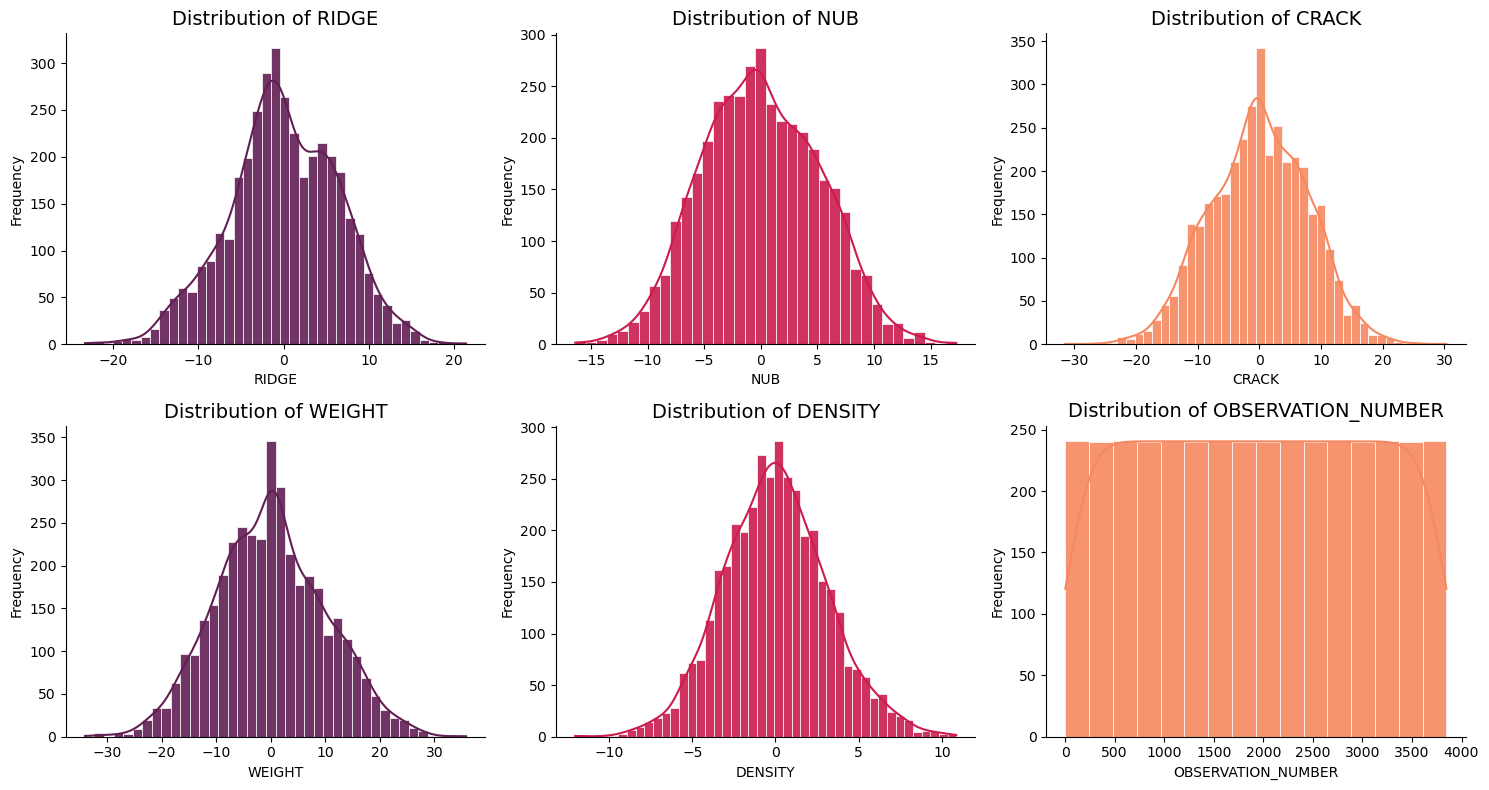

In [88]:
cols = df.columns
n_cols = 3
nrows = int(np.ceil(len(cols) / n_cols))
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=n_cols, 
    figsize=(n_cols*5, nrows*4), 
)
axes = np.array(axes).reshape(-1)

palette = sns.color_palette('rocket', n_cols)

for i, col in enumerate(cols):
    ax = axes[i]
    s = df[col].dropna()

    sns.histplot(
        s, 
        bins='auto', 
        kde=True, 
        ax=ax, 
        color=palette[i % len(palette)], 
        edgecolor='white', 
        linewidth=0.5, 
        alpha=0.9
    )

    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    sns.despine(ax=ax)

for j in range(len(cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig("pollen-distribution-hist.png")
plt.show()


#### 1.3.2 Correlations

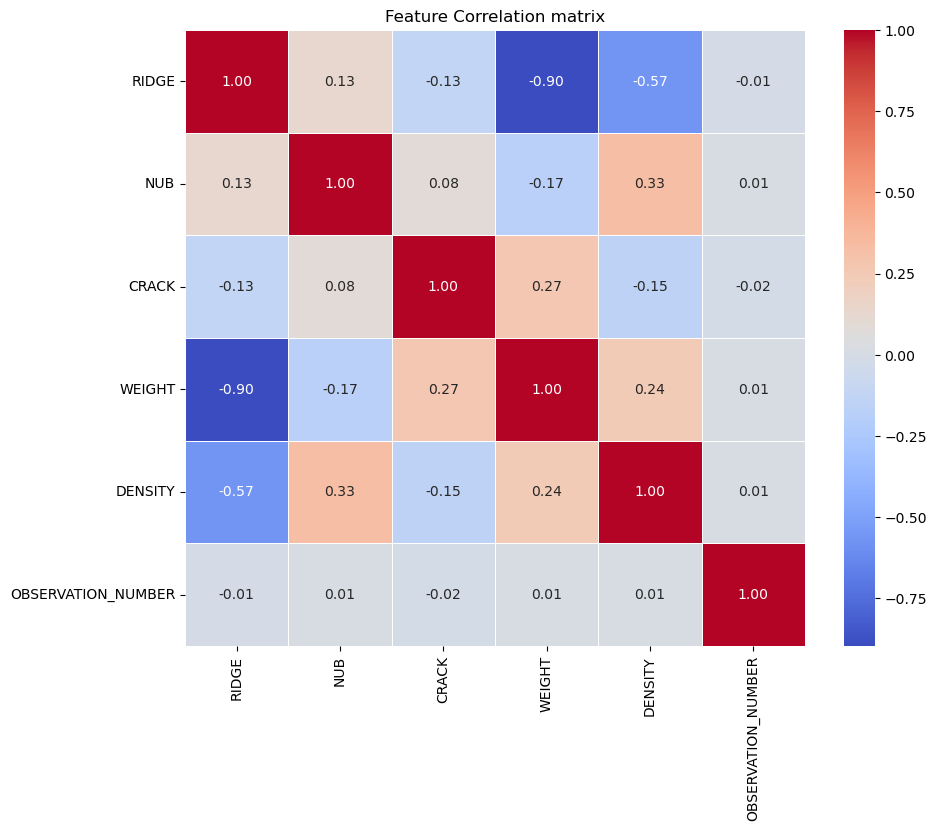

RIDGE   WEIGHT     0.896471
        DENSITY    0.565084
NUB     DENSITY    0.327398
CRACK   WEIGHT     0.268195
WEIGHT  DENSITY    0.242196
dtype: float64

In [89]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation matrix')
plt.show()

corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
high_corr = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
display(high_corr.head(5))

Highest correlation is 89% => do not drop any columns

#### 1.3.3 Visualizations

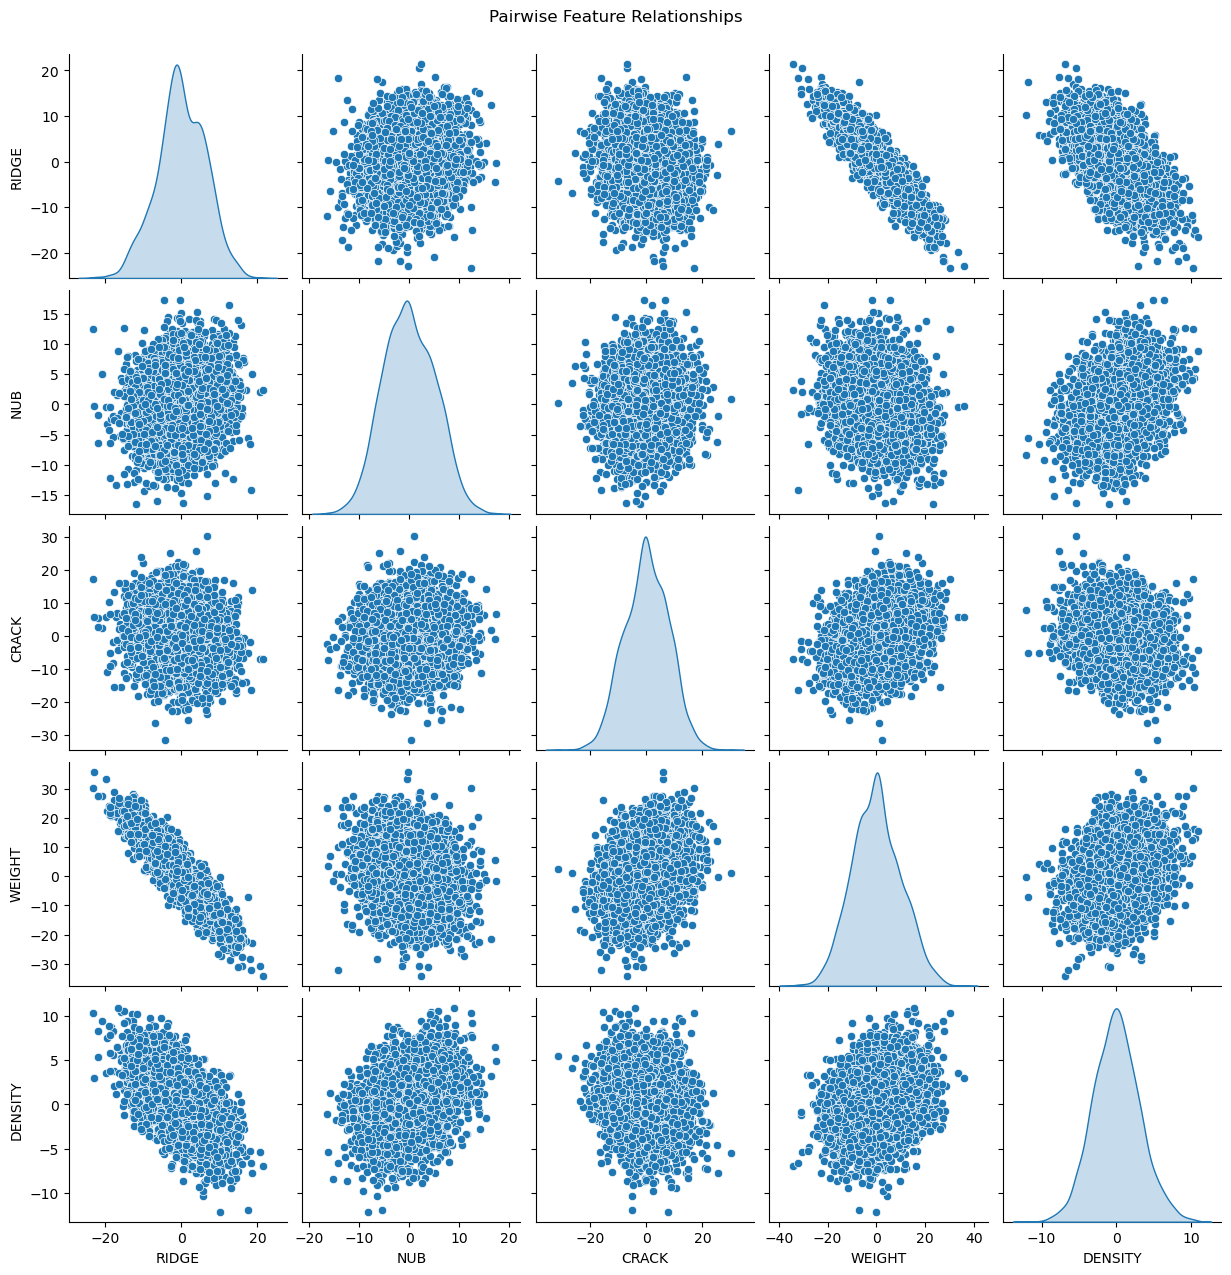

In [90]:
columns = df.columns.drop('OBSERVATION_NUMBER')
sns.pairplot(df[columns],  diag_kind='kde')
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

## 2 Data Cleaning and Preprocessing

### 2.1 Missing Values

There are no missing values in the dataset

In [91]:
df.isnull().sum().sum()

0

### 2.2 Duplicates

In [92]:
df_clean = df.drop_duplicates()
print(f"Dropped {df.shape[0] - df_clean.shape[0]} duplicate rows")

Dropped 0 duplicate rows


### 2.3 Train/Test Split

In [93]:
def tt_split(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    return X_train, X_test, y_train, y_test

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = tt_split(X, y)

Training set: (3078, 5), Test set: (770, 5)


### 2.4 Scaling and Encoding Pipelines

In [94]:
def build_preprocessor(numeric_cols, scaling=True):
    num_transformer = StandardScaler() if scaling else 'passthrough'
    
    return ColumnTransformer(
        transformers=[
            ('num', num_transformer, numeric_cols),
        ],
        remainder='drop'
    )

## 3 Train and Evaluate Baseline Models (sklearn)

### 3.1 Define Model Pipelines

In [95]:
print("Models:")
for model in BASELINE_MODELS.keys():
    print(BASELINE_MODELS[model])

print("\nModel params:")
for params in PARAM_GRIDS.keys():
    print(params, PARAM_GRIDS[params])

Models:
LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(n_jobs=12, random_state=42)

Model params:
decision_tree {'model__max_depth': [3, 5, 10, 20, 30, None], 'model__min_samples_split': [2, 5, 10, 20], 'model__min_samples_leaf': [1, 2, 4], 'model__criterion': ['squared_error']}
random_forest {'model__n_estimators': [100, 500, 1000, 1500], 'model__max_depth': [5, 10, 50, None], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 4], 'model__criterion': ['squared_error']}


### 3.2 Hyperparameter Randomized Search

In [96]:
best_params = {}

In [97]:
def rsv(X_train, y_train, model_name, param_distributions):
    columns = [col for col in df.columns if col not in [target]]
    preprocessor = build_preprocessor(columns, True)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', BASELINE_MODELS[model_name])
    ])
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=100,
        scoring=SCORING_METRICS,
        refit='rmse',
        n_jobs=5,
        cv=CV_FOLDS,
        random_state=RANDOM_SEED,
        verbose=3
    )
    rs.fit(X_train, y_train)
    return rs.best_params_

#### 3.3.1 Find best Hyperparameters

In [98]:
model_name = "decision_tree"
best_params[model_name] = rsv(X_train, y_train, model_name, RAND_DECISION_TREE)
best_params[model_name]

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[CV 1/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__min_samples_split=22; mae: (test=-1.466) rmse: (test=-1.870) total time=   0.0s
[CV 2/3] END model__criterion=squared_error, model__max_depth=40, model__min_samples_leaf=4, model__min_samples_split=16; mae: (test=-1.468) rmse: (test=-1.907) total time=   0.0s
[CV 2/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__min_samples_split=22; mae: (test=-1.443) rmse: (test=-1.862) total time=   0.0s
[CV 1/3] END model__criterion=squared_error, model__max_depth=40, model__min_samples_leaf=4, model__min_samples_split=16; mae: (test=-1.535) rmse: (test=-1.961) total time=   0.0s
[CV 3/3] END model__criterion=squared_error, model__max_depth=40, model__min_samples_leaf=4, model__min_samples_split=16; mae: (test=-1.439) rmse: (test=-1.850) total time=   0.0s
[CV 3/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__

{'model__criterion': 'squared_error',
 'model__max_depth': 22,
 'model__min_samples_leaf': 9,
 'model__min_samples_split': 8}

In [99]:
model_name = "random_forest"
best_params[model_name] = rsv(X_train, y_train, model_name, RAND_RANDOM_FOREST)
best_params[model_name]

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV 1/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-1.346) rmse: (test=-1.756) total time=   1.5s
[CV 2/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-1.355) rmse: (test=-1.749) total time=   1.6s
[CV 3/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-1.375) rmse: (test=-1.755) total time=   1.6s
[CV 2/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=41, model__max_features=None, model__min_samples_leaf=6, model__min_samples_split=22, mode

{'model__bootstrap': True,
 'model__criterion': 'squared_error',
 'model__max_depth': 23,
 'model__max_features': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 10,
 'model__n_estimators': 1347}

### 3.3 K-fold Cross Validation

In [100]:
columns = [col for col in df.columns if col not in [target]]

linear_regressor = Pipeline([
    ("preprocessor", build_preprocessor(numeric_cols=columns, scaling=True)),
    ("model", BASELINE_MODELS["linear"]),
])

best_decision_tree = Pipeline([
    ("preprocessor", build_preprocessor(numeric_cols=columns, scaling=False)),
    ("model", DecisionTreeRegressor(
        criterion=best_params['decision_tree']['model__criterion'],
        max_depth=best_params['decision_tree']['model__max_depth'],
        min_samples_leaf=best_params['decision_tree']['model__min_samples_leaf'],
        min_samples_split=best_params['decision_tree']['model__min_samples_split'],
        random_state=RANDOM_SEED,
    )),
])

best_random_forest = Pipeline([
    ("preprocessor", build_preprocessor(numeric_cols=columns,scaling=False)),
    ("model", RandomForestRegressor(
        criterion=best_params['random_forest']['model__criterion'],
        max_depth=10,
        min_samples_leaf=best_params['random_forest']['model__min_samples_leaf'],
        min_samples_split=best_params['random_forest']['model__min_samples_split'],
        n_estimators=1000,
        bootstrap=True,
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

standard_random_forest = Pipeline([
    ("preprocessor", build_preprocessor(numeric_cols=columns,scaling=False)),
    ("model", RandomForestRegressor(
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

few_deep_trees_random_forest = Pipeline([
    ("preprocessor", build_preprocessor(numeric_cols=columns,scaling=False)),
    ("model", RandomForestRegressor(
        n_estimators=10,
        max_depth=100,
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

sklearn_models = {
    "linear_regression": linear_regressor,
    "best_decision_tree": best_decision_tree,
    "best_random_forest": best_random_forest,
    "standard_random_forest": standard_random_forest,
    "few_deep_trees_random_forest": few_deep_trees_random_forest,
}

In [101]:
sklearn_cv_results = multiple_sklearn_cross_validate(sklearn_models, X_train, y_train)

Starting sklearn 5-Fold cross validation for model: linear_regression...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: best_decision_tree...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: best_random_forest...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: standard_random_forest...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: few_deep_trees_random_forest...
Starting sklearn 5-Fold cross validation...


In [102]:
sklearn_cv_results

,avg_fit_time,avg_score_time,avg_test_rmse,avg_train_rmse,avg_test_mae,avg_train_mae
linear_regression,0.020725,0.005085,-1.423463,-1.420756,-1.123040,-1.120484
best_decision_tree,0.014097,0.002849,-1.847093,-1.293866,-1.449877,-1.005306
best_random_forest,2.170133,0.130829,-1.547608,-0.993458,-1.214027,-0.786194
standard_random_forest,0.260795,0.022426,-1.560212,-0.585075,-1.221457,-0.454827
few_deep_trees_random_forest,0.026692,0.008246,-1.635377,-0.685491,-1.279562,-0.504483


### 3.4 Model Evaluation

In [103]:
sklearn_ho_results = sklearn_evaluate_holdout_performance(sklearn_models, X_train, y_train, X_test, y_test)

Evaluating holdout performance for model: linear_regression...
Evaluating holdout performance for model: best_decision_tree...
Evaluating holdout performance for model: best_random_forest...
Evaluating holdout performance for model: standard_random_forest...
Evaluating holdout performance for model: few_deep_trees_random_forest...


In [104]:
sklearn_ho_results

,fit_time,predict_time,RMSE,MAE,NRMSE
linear_regression,0.052808,0.014323,1.451799,1.163516,62.297152
best_decision_tree,0.017460,0.002256,1.859121,1.460970,79.775465
best_random_forest,2.690923,0.136930,1.587798,1.253388,68.132929
standard_random_forest,0.374822,0.018174,1.599840,1.264548,68.649672
few_deep_trees_random_forest,0.039851,0.008364,1.692168,1.334154,72.611460


## 4 Train and Evaluate Custom Implementations

In [105]:
best_custom_tree = RegressionTree(
    max_depth=best_params['decision_tree']['model__max_depth'],
    min_samples_split=best_params['decision_tree']['model__min_samples_split'],
    min_samples_leaf=best_params['decision_tree']['model__min_samples_leaf'],
    n_jobs=12,
    verbose=1
)
best_custom_random_forest = RandomForest(
    n_estimators=1347,
    max_depth=23,
    min_samples_split=best_params['random_forest']['model__min_samples_split'],
    min_samples_leaf=best_params['random_forest']['model__min_samples_leaf'],
    n_jobs=12,
    max_features = None,
    verbose=1
)
standard_custom_forest = RandomForest(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=12,
    max_features = None,
    verbose=1
)
few_deep_trees_custom_random_forest = RandomForest(
    n_estimators=10,
    max_depth=100,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=12,
    max_features = None,
    verbose=1)
custom_models = {
    "best_custom_tree": best_custom_tree,
    "best_custom_random_forest": best_custom_random_forest,
    "standard_custom_forest": standard_custom_forest,
    "few_deep_trees_custom_random_forest": few_deep_trees_custom_random_forest,
}

### 4.1 Cross Validation

In [ ]:
custom_cv_results = multiple_custom_cross_validate(
    custom_models,
    X=X_train,
    y=y_train,
)

Starting custom 5-Fold cross validation for model: best_custom_tree...
Starting 5-Fold cross validation...
Processing fold 1/5...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished


Fold 1/5 | Test RMSE: 1.85 | Train RMSE: 1.09
Processing fold 2/5...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished


Fold 2/5 | Test RMSE: 1.89 | Train RMSE: 1.13
Processing fold 3/5...


...

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished


Fold 4/5 | Test RMSE: 1.90 | Train RMSE: 1.13
Processing fold 5/5...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished


Fold 5/5 | Test RMSE: 2.04 | Train RMSE: 1.11
Starting custom 5-Fold cross validation for model: best_custom_random_forest...
Starting 5-Fold cross validation...
Processing fold 1/5...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    7.5s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   34.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:  1.3min


In [ ]:
custom_cv_results

,avg_train_rmse,avg_test_rmse,avg_train_mae,avg_test_mae,avg_train_nrmse,avg_test_nrmse,avg_fit_time,avg_score_time
best_custom_tree,1.107037,1.938821,0.848739,1.494669,-35.223953,-56.201712,0.303453,0.011558
many_trees_custom_random_forest,0.921305,1.546986,0.729514,1.211402,-24.679410,-54.316611,610.123469,2.362107
standard_custom_forest,0.586827,1.555740,0.455923,1.213389,22.197108,-6.557415,184.653754,2.132772
few_deep_trees_custom_random_forest,0.690393,1.646797,0.503958,1.283191,-7.216067,8.298903,6.893751,0.219739


### 4.2 Evaluation

In [ ]:
custom_ho_results = custom_evaluate_holdout_performance(custom_models, X_train, y_train, X_test, y_test)

Evaluating holdout performance for model: best_custom_tree...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   5 out of   5 | elapsed:    0.0s finished


Evaluating holdout performance for model: many_trees_custom_random_forest...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   54.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  5.5min
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed: 13.2min
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed: 15.2min finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  28 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    3.1s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Evaluating holdout performance for model: standard_custom_forest...


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   54.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:  3.3min finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.0s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Evaluating holdout performance for model: few_deep_trees_custom_random_forest...


[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    7.5s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    0.3s finished


In [ ]:
custom_ho_results

,fit_time,predict_time,RMSE,MAE,NRMSE
best_custom_tree,2.149740,0.024088,1.970725,1.521547,84.564448
many_trees_custom_random_forest,914.691837,3.190998,1.586894,1.253786,68.094124
standard_custom_forest,195.318364,2.047179,1.601939,1.264524,68.739719
few_deep_trees_custom_random_forest,7.551914,0.263886,1.657178,1.313849,71.110058


### 4.3 Comparison: sklearn vs Custom Implementations

In [ ]:
sklearn_cv_results = pd.read_csv('pollen/sklearn_cross_validation_results.csv', index_col=0)
custom_cv_results = pd.read_csv('pollen/custom_cross_validation_results.csv', index_col=0)
sklearn_ho_results = pd.read_csv('pollen/sklearn_holdout_performance_results.csv', index_col=0)
custom_ho_results = pd.read_csv('pollen/custom_holdout_performance_results.csv', index_col=0)

In [ ]:
sklearn_cv_results

,avg_fit_time,avg_score_time,avg_test_rmse,avg_train_rmse,avg_test_mae,avg_train_mae
linear_regression,0.007003,0.002303,-1.423463,-1.420756,-1.123040,-1.120484
best_decision_tree,0.009949,0.001665,-1.847093,-1.293866,-1.449877,-1.005306
many_trees_random_forest,1.846358,0.106132,-1.547608,-0.993458,-1.214027,-0.786194
standard_random_forest,0.180806,0.017994,-1.560212,-0.585075,-1.221457,-0.454827
few_deep_trees_random_forest,0.023423,0.006644,-1.635377,-0.685491,-1.279562,-0.504483


In [ ]:
sklearn_ho_results

,fit_time,predict_time,RMSE,MAE,NRMSE
linear_regression,0.006438,0.001791,1.451799,1.163516,62.297152
best_decision_tree,0.012656,0.001543,1.859121,1.460970,79.775465
many_trees_random_forest,1.733441,0.086638,1.587798,1.253388,68.132929
standard_random_forest,0.205796,0.016007,1.599840,1.264548,68.649672
few_deep_trees_random_forest,0.027672,0.004652,1.692168,1.334154,72.611460


In [ ]:
custom_cv_results

,avg_train_rmse,avg_test_rmse,avg_train_mae,avg_test_mae,avg_train_nrmse,avg_test_nrmse,avg_fit_time,avg_score_time
best_custom_tree,1.107037,1.938821,0.848739,1.494669,-35.223953,-56.201712,0.303453,0.011558
many_trees_custom_random_forest,0.921305,1.546986,0.729514,1.211402,-24.679410,-54.316611,610.123469,2.362107
standard_custom_forest,0.586827,1.555740,0.455923,1.213389,22.197108,-6.557415,184.653754,2.132772
few_deep_trees_custom_random_forest,0.690393,1.646797,0.503958,1.283191,-7.216067,8.298903,6.893751,0.219739


In [ ]:
custom_ho_results

,fit_time,predict_time,RMSE,MAE,NRMSE
best_custom_tree,2.149740,0.024088,1.970725,1.521547,84.564448
many_trees_custom_random_forest,914.691837,3.190998,1.586894,1.253786,68.094124
standard_custom_forest,195.318364,2.047179,1.601939,1.264524,68.739719
few_deep_trees_custom_random_forest,7.551914,0.263886,1.657178,1.313849,71.110058


In [ ]:
import plot
reload(plot)
from plot import plot_cv_comparison, plot_holdout_comparison, plot_overfitting_comparison

model_pairs = {
    "Best Tree": ["best_decision_tree", "best_custom_tree"],
    "Best RF": ["best_random_forest", "best_custom_random_forest"],
    "Standard RF": ["standard_random_forest", "standard_custom_forest"],
    "Few Deep RF": ["few_deep_trees_random_forest", "few_deep_trees_custom_random_forest"],
}

sklearn_only = {"Linear Regression": "linear_regression"}

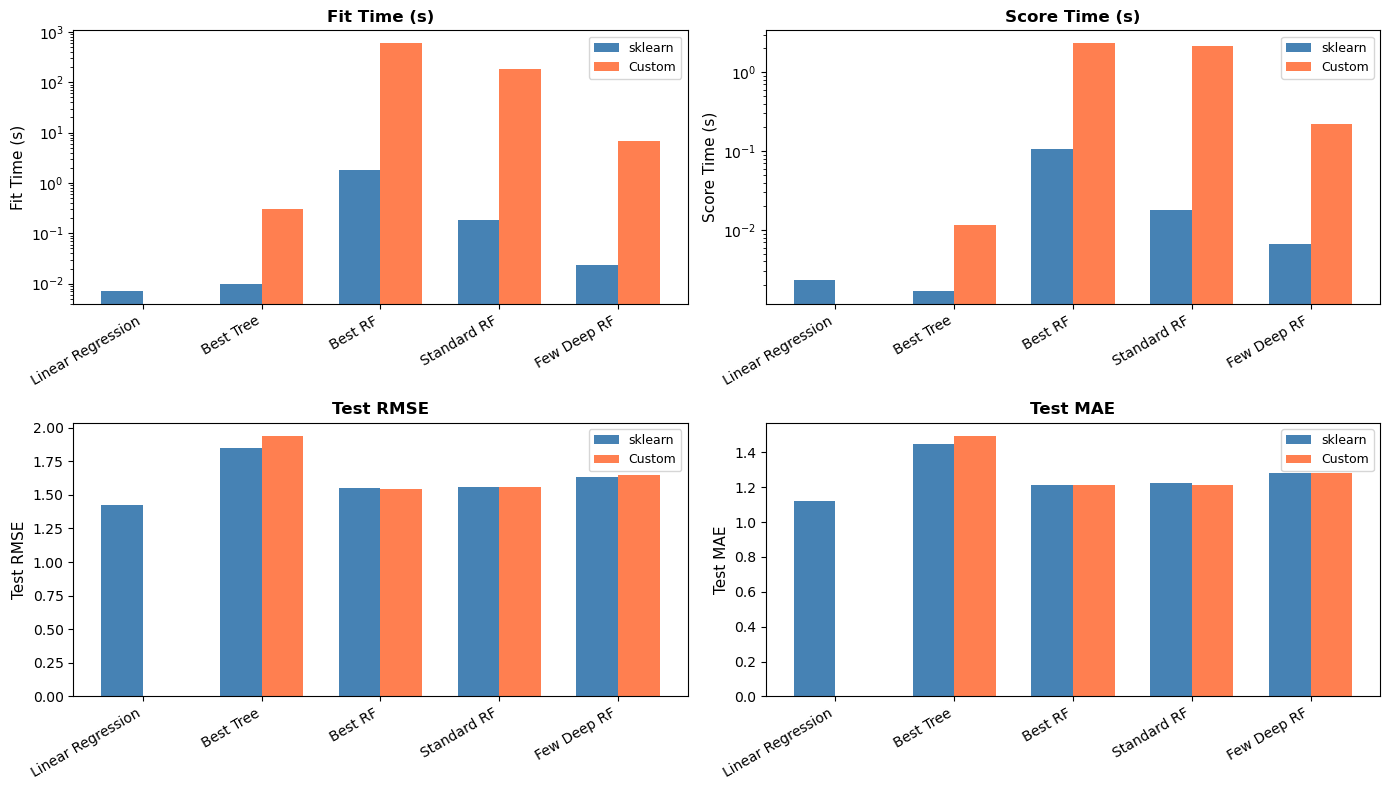

In [ ]:
fig_cv = plot_cv_comparison(sklearn_cv_results, custom_cv_results, model_pairs, sklearn_only)
plt.savefig("pollen/pollen-cv.png")
plt.show()

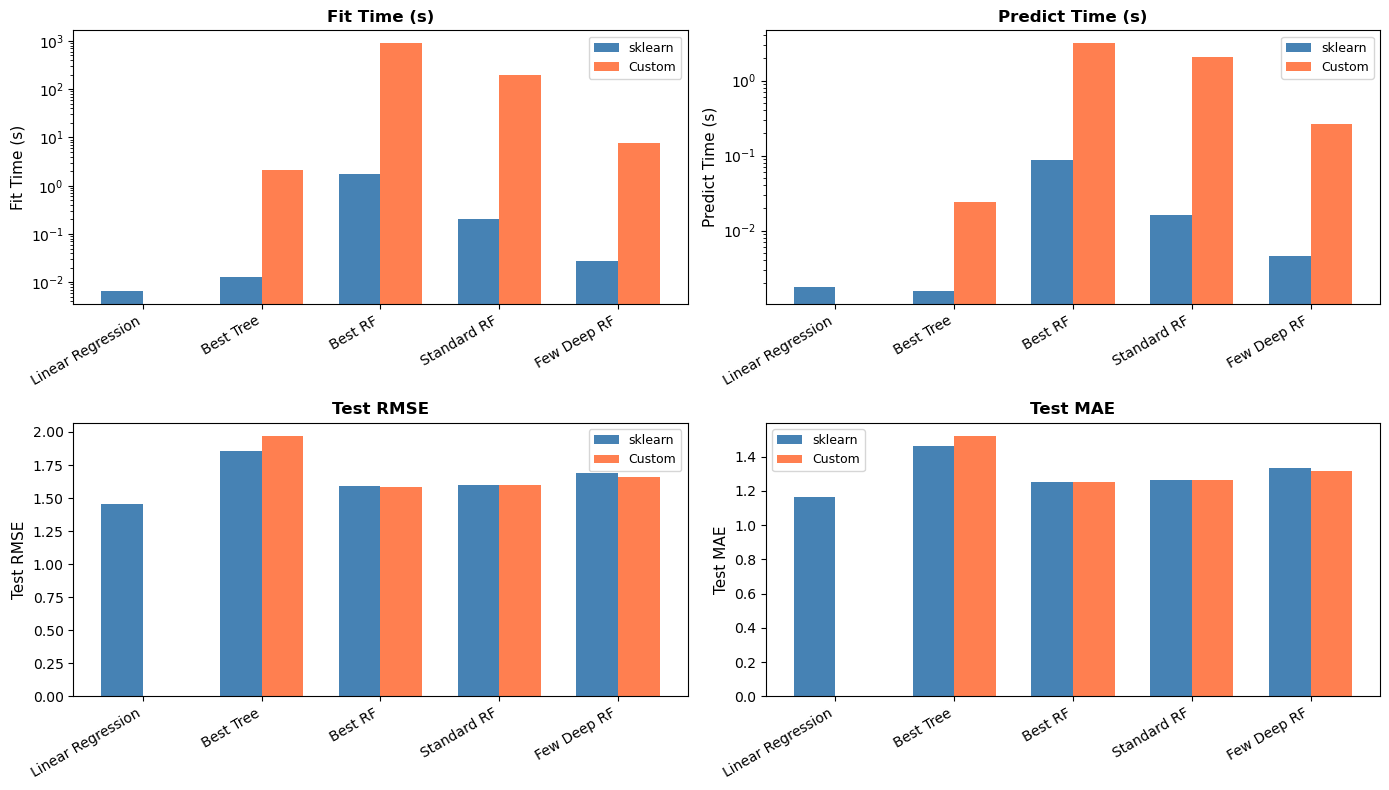

In [ ]:
fig_ho = plot_holdout_comparison(sklearn_ho_results, custom_ho_results, model_pairs, sklearn_only)
plt.savefig("pollen/pollen-ho.png")
plt.show()

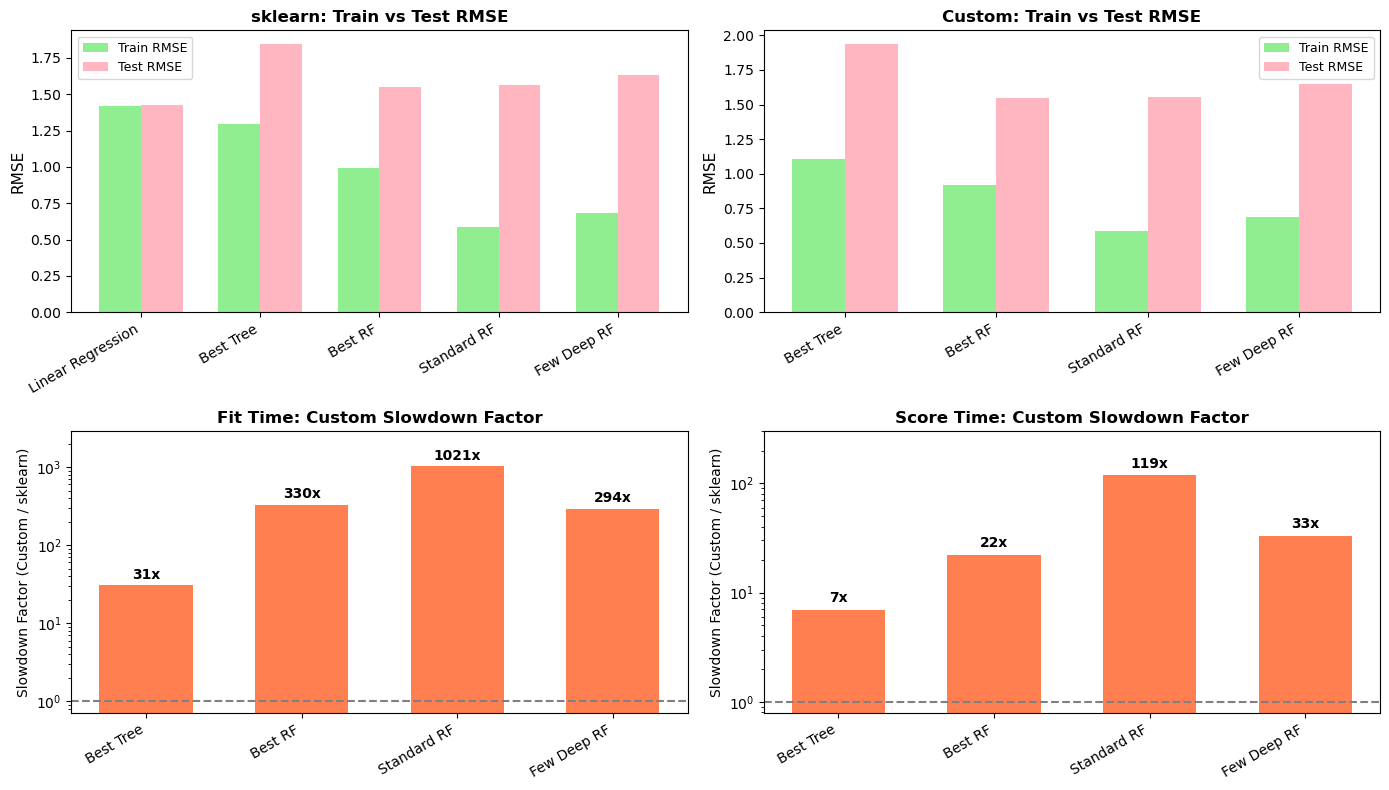

In [ ]:
fig_overfit = plot_overfitting_comparison(sklearn_cv_results, custom_cv_results, model_pairs, sklearn_only)
plt.savefig("pollen/pollen-of.png")
plt.show()